In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Loading and Cleaning

In [4]:
df = pd.read_csv("IPL Matches 2008-2020.csv")
print("Dataset loaded as successfully!")
df.head()

Dataset loaded as successfully!


,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan


## 1.dataset ka size


In [5]:
print("Rows :", df.shape[0])

Rows : 816


In [6]:
print("Columns :", df.shape[1])

Columns : 17


In [7]:
# all coumns
print(df.columns)

Index(['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    int64  
 1   city             803 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  812 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    int64  
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           812 non-null    object 
 11  result           812 non-null    object 
 12  result_margin    799 non-null    float64
 13  eliminator       812 non-null    object 
 14  method           19 non-null     object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    object 
dtypes: float64(1), i

In [9]:
# missing value check

print(df.isnull().sum())

id                   0
city                13
date                 0
player_of_match      4
venue                0
neutral_venue        0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               4
result               4
result_margin       17
eliminator           4
method             797
umpire1              0
umpire2              0
dtype: int64


In [10]:
missing = df.isnull().sum()
print(missing[missing > 0])

city                13
player_of_match      4
winner               4
result               4
result_margin       17
eliminator           4
method             797
dtype: int64


In [11]:
columns = ['city','player_of_match','winner','result','result_margin','eliminator','method']
for col in columns:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

In [12]:
# check fillna

print(df.isnull().sum())

id                 0
city               0
date               0
player_of_match    0
venue              0
neutral_venue      0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
eliminator         0
method             0
umpire1            0
umpire2            0
dtype: int64


In [13]:
# check duplicate rows

print("Duplicate rows :", df.duplicated().sum())

Duplicate rows : 0


# EDA

## 1.Total matches per season

In [14]:
print(df.columns.tolist())

['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2']


In [21]:
df['date'] = pd.to_datetime(df['date'])
df['season'] = df['date'].dt.year
print(df[['date','season']])

          date  season
0   2008-04-18    2008
1   2008-04-19    2008
2   2008-04-19    2008
3   2008-04-20    2008
4   2008-04-20    2008
..         ...     ...
811 2020-09-28    2020
812 2020-11-05    2020
813 2020-11-06    2020
814 2020-11-08    2020
815 2020-11-10    2020

[816 rows x 2 columns]


In [24]:
season_matches = df.groupby('season').size().reset_index(name='matches')

print(season_matches)

    season  matches
0     2008       58
1     2009       57
2     2010       60
3     2011       73
4     2012       74
5     2013       76
6     2014       60
7     2015       59
8     2016       60
9     2017       59
10    2018       60
11    2019       60
12    2020       60


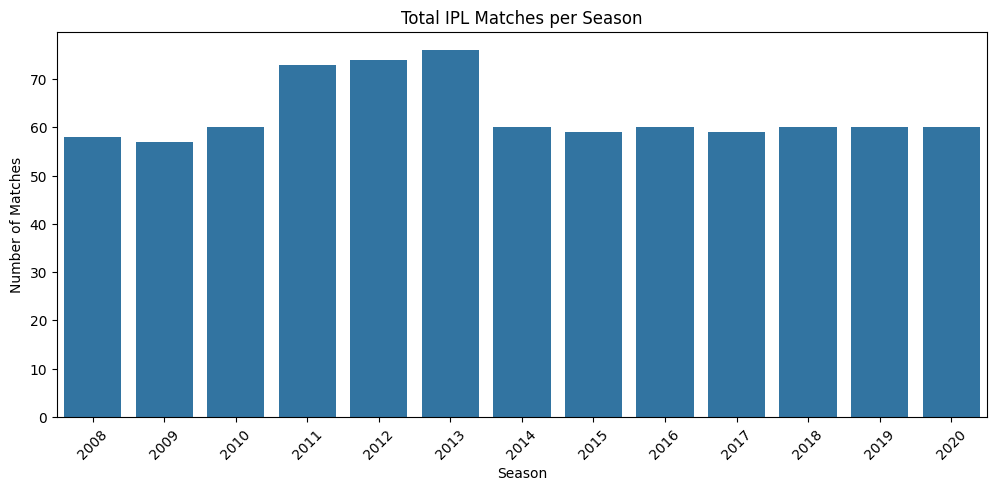

In [26]:
# graph

plt.figure(figsize=(12,5))

sns.barplot(
    data=season_matches,
    x='season',
    y='matches'
)

plt.title('Total IPL Matches per Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')

plt.xticks(rotation=45)
plt.show()

## 2.Team-wise Total Matches, Wins Losses


In [27]:
teams = pd.unique(df[['team1','team2']].values.ravel())

print(teams)

['Royal Challengers Bangalore' 'Kolkata Knight Riders' 'Kings XI Punjab'
 'Chennai Super Kings' 'Delhi Daredevils' 'Rajasthan Royals'
 'Mumbai Indians' 'Deccan Chargers' 'Kochi Tuskers Kerala' 'Pune Warriors'
 'Sunrisers Hyderabad' 'Rising Pune Supergiants' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Delhi Capitals']


In [30]:
# har team ke matches, wins, losses

team_stats = []

for team in teams:

    matches = ((df['team1'] == team) | (df['team2'] == team)).sum()

    wins = (df['winner'] == team).sum()

    losses = matches - wins

    team_stats.append({
        'Team': team,
        'Matches': matches,
        'Wins': wins,
        'Losses': losses
    })

team_stats = pd.DataFrame(team_stats)
print(team_stats)

                           Team  Matches  Wins  Losses
0   Royal Challengers Bangalore      195    91     104
1         Kolkata Knight Riders      192    99      93
2               Kings XI Punjab      190    88     102
3           Chennai Super Kings      178   106      72
4              Delhi Daredevils      161    67      94
5              Rajasthan Royals      161    81      80
6                Mumbai Indians      203   120      83
7               Deccan Chargers       75    29      46
8          Kochi Tuskers Kerala       14     6       8
9                 Pune Warriors       46    12      34
10          Sunrisers Hyderabad      124    66      58
11      Rising Pune Supergiants       14     5       9
12                Gujarat Lions       30    13      17
13       Rising Pune Supergiant       16    10       6
14               Delhi Capitals       33    19      14


In [31]:
print(team_stats.head())

                          Team  Matches  Wins  Losses
0  Royal Challengers Bangalore      195    91     104
1        Kolkata Knight Riders      192    99      93
2              Kings XI Punjab      190    88     102
3          Chennai Super Kings      178   106      72
4             Delhi Daredevils      161    67      94


In [34]:
team_stats = team_stats.sort_values(
    by= 'Wins',
    ascending=False
)
print(team_stats)

                           Team  Matches  Wins  Losses
6                Mumbai Indians      203   120      83
3           Chennai Super Kings      178   106      72
1         Kolkata Knight Riders      192    99      93
0   Royal Challengers Bangalore      195    91     104
2               Kings XI Punjab      190    88     102
5              Rajasthan Royals      161    81      80
4              Delhi Daredevils      161    67      94
10          Sunrisers Hyderabad      124    66      58
7               Deccan Chargers       75    29      46
14               Delhi Capitals       33    19      14
12                Gujarat Lions       30    13      17
9                 Pune Warriors       46    12      34
13       Rising Pune Supergiant       16    10       6
8          Kochi Tuskers Kerala       14     6       8
11      Rising Pune Supergiants       14     5       9


## 3. Most successful Team

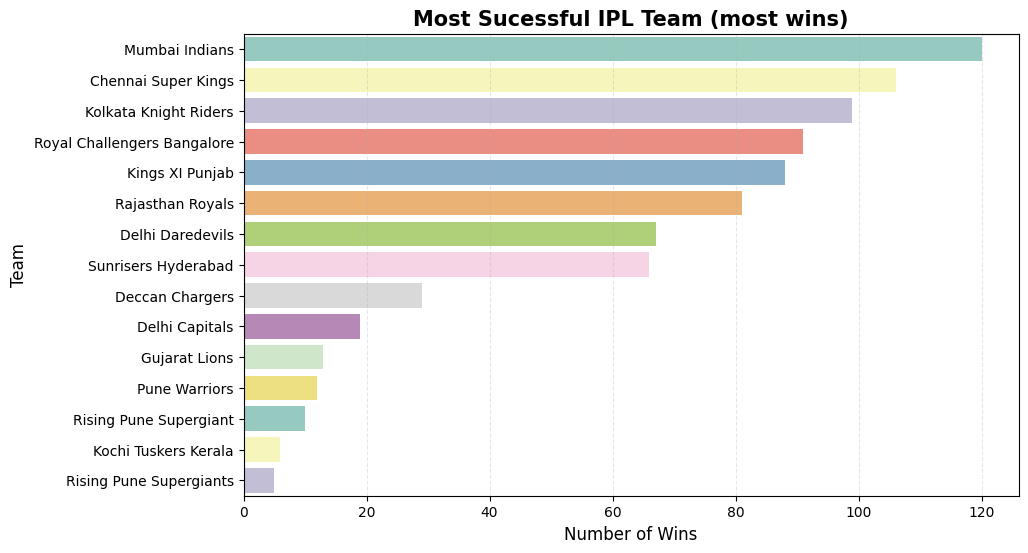

In [58]:
import os
# Image ke liye folder 
output_dir = 'IPL_Plots'
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(10,6))
sns.barplot(x='Wins',y='Team', data=team_stats,hue='Team',palette='Set3')

plt.title('Most Sucessful IPL Team (most wins)',fontsize=15, fontweight='bold')
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Team',fontsize=12)
plt.grid(axis='x', linestyle='--',alpha=0.3)

plt.savefig(os.path.join(output_dir, 'most_successful_teams.png'), dpi=300, bbox_inches='tight')

plt.show()

## 4. Player of the Matches

In [64]:
# top 10 player of the match award count

top_players = df['player_of_match'].value_counts().head(10)
print(top_players)

player_of_match
AB de Villiers    23
CH Gayle          22
RG Sharma         18
DA Warner         17
MS Dhoni          17
SR Watson         16
YK Pathan         16
SK Raina          14
G Gambhir         13
V Kohli           13
Name: count, dtype: int64


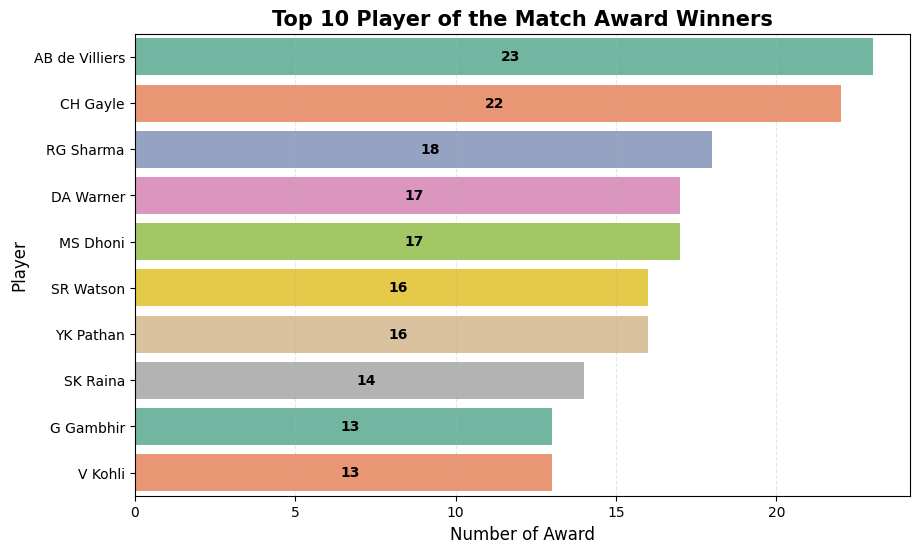

In [70]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_players.values, y=top_players.index, hue=top_players.index, palette='Set2', legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=5,label_type='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Player of the Match Award Winners', fontsize=15, fontweight='bold')
plt.xlabel('Number of Award', fontsize=12)
plt.ylabel('Player', fontsize=12)
plt.grid(axis='x',linestyle='--',alpha=0.3)

plt.savefig(os.path.join(output_dir, 'top_player_of_matches.png'), dpi=300, bbox_inches='tight')

plt.show()